# Sherlock Holmes GPT — a tiny transformer trained from scratch

This builds a small GPT-style model that learns to write like Arthur Conan Doyle, one character at a time. No pretrained weights, no shortcuts — self-attention, transformer blocks, and the training loop are all written out below so you can see exactly what's going on.

The model reads a chunk of Sherlock Holmes text and tries to guess the next character, over and over, until it starts picking up on spelling, punctuation, dialogue formatting, and eventually some actual sentence structure. Don't expect real prose out of something this small — the goal is watching it go from random noise to something that at least *looks* like English.

## Getting some text to train on

We'll pull a handful of Sherlock Holmes books straight from Project Gutenberg and combine them into one file. More text than a single book means the model has more to learn from without needing to memorize everything.

In [1]:
import urllib.request
import re
import os

# Project Gutenberg IDs for a handful of Conan Doyle's Sherlock Holmes books
BOOKS = {
    "A Study in Scarlet": 244,
    "The Sign of the Four": 2097,
    "The Adventures of Sherlock Holmes": 1661,
    "The Memoirs of Sherlock Holmes": 834,
    "The Hound of the Baskervilles": 2852,
}

DATA_PATH = "input.txt"

def strip_gutenberg_boilerplate(raw_text):
    # cuts out the license header/footer, keeps the actual book
    start_match = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", raw_text)
    end_match = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", raw_text)
    start = start_match.end() if start_match else 0
    end = end_match.start() if end_match else len(raw_text)
    return raw_text[start:end].strip()

FALLBACK_TEXT = """Mr. Sherlock Holmes, who was usually very late in the mornings, save upon
those not infrequent occasions when he was up all night, was seated at
the breakfast table. I stood upon the hearth-rug and picked up the
stick which our visitor had left behind him the night before.

"To Sherlock Holmes she is always the woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her sex."

"Come, Watson, come!" he cried. "The game is afoot. Not a word! Into
your clothes and come!"

It was a bitter night, so we drew our ulsters tight about our throats.
Overhead the stars were shining coldly and brightly, while the
breath of the pedestrians blew out into smoke like so many pistol
shots. Our footfalls rang out crisply and loudly as we swung through
the doctors' quarter, Wimpole Street, Harley Street, and so through
Wigmore Street into Oxford Street.

"You have a grand gift of silence, Watson," said Holmes. "It makes
you quite invaluable as a companion. Upon my word, it is a great
thing for me to have someone I can talk to, for my own thoughts are
not over-pleasant."
""" * 60

if not os.path.exists(DATA_PATH):
    all_text = []
    for title, book_id in BOOKS.items():
        url = f"https://www.gutenberg.org/ebooks/{book_id}.txt.utf-8"
        try:
            print(f"Downloading '{title}'...")
            raw = urllib.request.urlopen(url, timeout=15).read().decode("utf-8")
            all_text.append(strip_gutenberg_boilerplate(raw))
        except Exception as e:
            print(f"  couldn't get '{title}' ({e}), skipping")

    if all_text:
        text = "\n\n".join(all_text)
    else:
        print("No internet access — falling back to a small built-in sample.")
        text = FALLBACK_TEXT

    with open(DATA_PATH, "w", encoding="utf-8") as f:
        f.write(text)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"\nTotal training text: {len(text):,} characters")


Total training text: 1,957,432 characters
A STUDY IN SCARLET

By A. Conan Doyle




CONTENTS

 A STUDY IN SCARLET.

 PART I.
 CHAPTER I. MR. SHERLOCK HOLMES.
 CHAPTER II. THE SCIENCE OF DEDUCTION.
 CHAPTER III. THE LAURISTON GARDENS MYSTERY
 CHAPTER IV. WHAT JOHN RANCE HAD TO TELL.
 CHAPTER V. OUR ADVERTISEMENT BRINGS A VISITOR.
 CHAPTER VI


## Turning text into numbers

Neural nets don't read letters, so every unique character in the text gets mapped to an integer. It's a crude tokenizer compared to what real LLMs use (they split on sub-words, not single characters), but it's simple and it works fine at this scale.

In [2]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("vocab size:", vocab_size)
print("".join(chars))

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda l: "".join(itos[i] for i in l)

encode(text[:20])

vocab size: 100

 !&(),-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyz£º½àâæçèéêîïñôöûüœ—‘’“”


[22, 1, 40, 41, 42, 25, 46, 1, 30, 35, 1, 40, 24, 22, 39, 33, 26, 41, 0, 0]

In [3]:
import torch

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

len(train_data), len(val_data)

(1761688, 195744)

## Settings

Kept small on purpose — this trains in a couple of minutes on a normal CPU. If you've got a GPU lying around, cranking up `n_embd`, `n_layer`, and `max_iters` will get you noticeably better output.

In [4]:
batch_size = 32
block_size = 64      # how many characters of context the model looks at
n_embd = 96          # embedding size
n_head = 4
n_layer = 4
dropout = 0.1
max_iters = 1200
eval_interval = 200
eval_iters = 20
learning_rate = 3e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1337)
device

'cuda'

In [5]:
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+1+block_size] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
xb.shape, yb.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

## The model

A few pieces stacked together:

- **attention head** — each position looks back at earlier positions and decides which ones matter
- **multi-head attention** — a few of those heads running side by side, concatenated
- **feed-forward** — a small MLP applied to each position on its own
- **block** — attention + feed-forward, wrapped in residual connections and layer norm
- the full model is just token embeddings + position embeddings, a stack of blocks, and a linear layer at the end predicting the next character

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (C ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # can't peek ahead
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = self.blocks(tok_emb + pos_emb)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

model = GPTLanguageModel().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params/1e6:.2f}M parameters")

0.47M parameters


## Training

In [7]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses, val_losses, steps = [], [], []

for it in range(max_iters):
    if it % eval_interval == 0 or it == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps.append(it)
        print(f"step {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step     0 | train 4.7514 | val 4.7445
step   200 | train 2.5478 | val 2.4419
step   400 | train 2.4163 | val 2.2826
step   600 | train 2.3232 | val 2.2014
step   800 | train 2.2658 | val 2.1242
step  1000 | train 2.1677 | val 2.0289
step  1199 | train 2.0787 | val 1.9637


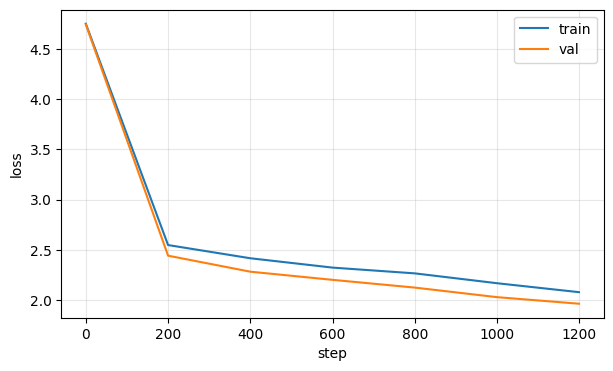

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(steps, train_losses, label="train")
plt.plot(steps, val_losses, label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Generating text

Start from an empty prompt and let the model ramble.

In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
out = model.generate(context, max_new_tokens=300, temperature=0.8, top_k=40)
print(decode(out[0].tolist()))


      it of nit wha out than wat thrin byonoon wn my unrmed the therrytinghory tas eat. Hereree att the  reeras my icou whingusy but seas aingg ines asendy ondite bysifelyt, hadoly, as hakndsteve sthe were bulus trour sily. I agnon, her in tled ond s rob! Nowine nat t sheeas pof in the tweave ankere


In [10]:
def generate_from_prompt(prompt, max_new_tokens=200, temperature=0.8, top_k=40):
    ids = encode(prompt) or [0]
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())

print(generate_from_prompt("Holmes turned to me and said, "))

Holmes turned to me and said, twas said the whas kut geroked taco I fremy harond leeded sowe?”

          “I thor whe hand becr whes musaackend on ther mat, wee suced. Thim wo as dewioouldoud than thesel fblon oplen ichires for se


## Saving it

So it can be reloaded later without training all over again.

In [11]:
torch.save({
    "model_state_dict": model.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "config": {
        "vocab_size": vocab_size,
        "n_embd": n_embd,
        "n_head": n_head,
        "n_layer": n_layer,
        "block_size": block_size,
        "dropout": dropout,
    },
}, "gpt_model.pt")

print("saved to gpt_model.pt")

saved to gpt_model.pt


---

A few things worth trying if you want to push this further: more training steps, a bigger `n_embd`/`n_layer`, or swapping in a different set of books entirely — the pipeline above doesn't care what text it's fed, as long as it's plain `.txt`.